In [ ]:
import pandas as pd

files = [
    "/content/202310-divvy-tripdata.csv",
    "/content/202302-divvy-tripdata.csv",
    "/content/202402-divvy-tripdata.csv",
    "/content/202301-divvy-tripdata.csv",
    "/content/202303-divvy-tripdata.csv",
    "/content/202308-divvy-tripdata.csv",
    "/content/202405-divvy-tripdata.csv"
]

df_list = [pd.read_csv(f) for f in files]

df = pd.concat(df_list, ignore_index=True)

print("Shape:", df.shape)
df.head()

Shape: (2780887, 13)


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,4449097279F8BBE7,classic_bike,2023-10-08 10:36:26,2023-10-08 10:49:19,Orleans St & Chestnut St (NEXT Apts),620,Sheffield Ave & Webster Ave,TA1309000033,41.898203,-87.637536,41.921540,-87.653818,member
1,9CF060543CA7B439,electric_bike,2023-10-11 17:23:59,2023-10-11 17:36:08,Desplaines St & Kinzie St,TA1306000003,Sheffield Ave & Webster Ave,TA1309000033,41.888641,-87.644415,41.921540,-87.653818,member
2,667F21F4D6BDE69C,electric_bike,2023-10-12 07:02:33,2023-10-12 07:06:53,Orleans St & Chestnut St (NEXT Apts),620,Franklin St & Lake St,TA1307000111,41.898073,-87.637514,41.885837,-87.635500,member
3,F92714CC6B019B96,classic_bike,2023-10-24 19:13:03,2023-10-24 19:18:29,Desplaines St & Kinzie St,TA1306000003,Franklin St & Lake St,TA1307000111,41.888716,-87.644448,41.885837,-87.635500,member
4,5E34BA5DE945A9CC,classic_bike,2023-10-09 18:19:26,2023-10-09 18:30:56,Desplaines St & Kinzie St,TA1306000003,Franklin St & Lake St,TA1307000111,41.888716,-87.644448,41.885837,-87.635500,member


In [ ]:
# 1. Convert to datetime
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])

# 2. Create trip duration (in minutes)
df['trip_duration'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60

# 3. Remove invalid trips (negative or zero duration)
df = df[df['trip_duration'] > 0]

# 4. Handle missing station names (IMPORTANT decision)
df['start_station_name'].fillna("Unknown Start", inplace=True)
df['end_station_name'].fillna("Unknown End", inplace=True)

# 5. Drop rows where coordinates are missing (strict)
df = df.dropna(subset=['start_lat', 'start_lng', 'end_lat', 'end_lng'])

# 6. Reset index
df = df.reset_index(drop=True)

print("After cleaning:", df.shape)
df.head()

/tmp/ipykernel_466/3592212625.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['start_station_name'].fillna("Unknown Start", inplace=True)
/tmp/ipykernel_466/3592212625.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

After cleaning: (2776769, 14)


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,trip_duration
0,4449097279F8BBE7,classic_bike,2023-10-08 10:36:26,2023-10-08 10:49:19,Orleans St & Chestnut St (NEXT Apts),620,Sheffield Ave & Webster Ave,TA1309000033,41.898203,-87.637536,41.921540,-87.653818,member,12.883333
1,9CF060543CA7B439,electric_bike,2023-10-11 17:23:59,2023-10-11 17:36:08,Desplaines St & Kinzie St,TA1306000003,Sheffield Ave & Webster Ave,TA1309000033,41.888641,-87.644415,41.921540,-87.653818,member,12.150000
2,667F21F4D6BDE69C,electric_bike,2023-10-12 07:02:33,2023-10-12 07:06:53,Orleans St & Chestnut St (NEXT Apts),620,Franklin St & Lake St,TA1307000111,41.898073,-87.637514,41.885837,-87.635500,member,4.333333
3,F92714CC6B019B96,classic_bike,2023-10-24 19:13:03,2023-10-24 19:18:29,Desplaines St & Kinzie St,TA1306000003,Franklin St & Lake St,TA1307000111,41.888716,-87.644448,41.885837,-87.635500,member,5.433333
4,5E34BA5DE945A9CC,classic_bike,2023-10-09 18:19:26,2023-10-09 18:30:56,Desplaines St & Kinzie St,TA1306000003,Franklin St & Lake St,TA1307000111,41.888716,-87.644448,41.885837,-87.635500,member,11.500000


In [ ]:
import numpy as np

# 1. Data type (what kind of data is being used)
df['data_type'] = 'location'

# 2. Purpose of data usage (logic-based, not random)
conditions = [
    df['trip_duration'] < 10,
    (df['trip_duration'] >= 10) & (df['trip_duration'] < 30),
    df['trip_duration'] >= 30
]

choices = ['navigation', 'analytics', 'marketing']

df['purpose'] = np.select(conditions, choices, default='other')

# 3. Consent (realistic logic)
df['consent'] = np.where(df['member_casual'] == 'member', 'yes', 'no')

# 4. Data sharing (risk factor)
df['data_shared'] = np.where(df['purpose'] == 'marketing', 'yes', 'no')

# 5. Retention period (based on purpose)
retention_map = {
    'navigation': 1,
    'analytics': 30,
    'marketing': 180
}

df['retention_days'] = df['purpose'].map(retention_map)

df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,trip_duration,data_type,purpose,consent,data_shared,retention_days
0,4449097279F8BBE7,classic_bike,2023-10-08 10:36:26,2023-10-08 10:49:19,Orleans St & Chestnut St (NEXT Apts),620,Sheffield Ave & Webster Ave,TA1309000033,41.898203,-87.637536,41.921540,-87.653818,member,12.883333,location,analytics,yes,no,30
1,9CF060543CA7B439,electric_bike,2023-10-11 17:23:59,2023-10-11 17:36:08,Desplaines St & Kinzie St,TA1306000003,Sheffield Ave & Webster Ave,TA1309000033,41.888641,-87.644415,41.921540,-87.653818,member,12.150000,location,analytics,yes,no,30
2,667F21F4D6BDE69C,electric_bike,2023-10-12 07:02:33,2023-10-12 07:06:53,Orleans St & Chestnut St (NEXT Apts),620,Franklin St & Lake St,TA1307000111,41.898073,-87.637514,41.885837,-87.635500,member,4.333333,location,navigation,yes,no,1
3,F92714CC6B019B96,classic_bike,2023-10-24 19:13:03,2023-10-24 19:18:29,Desplaines St & Kinzie St,TA1306000003,Franklin St & Lake St,TA1307000111,41.888716,-87.644448,41.885837,-87.635500,member,5.433333,location,navigation,yes,no,1
4,5E34BA5DE945A9CC,classic_bike,2023-10-09 18:19:26,2023-10-09 18:30:56,Desplaines St & Kinzie St,TA1306000003,Franklin St & Lake St,TA1307000111,41.888716,-87.644448,41.885837,-87.635500,member,11.500000,location,analytics,yes,no,30


In [ ]:
df['purpose'].value_counts()

,count
purpose,
navigation,1499499
analytics,1033438
marketing,243832


In [ ]:
import numpy as np

# Randomly flip consent for some users (simulate missing consent logs)
mask1 = np.random.rand(len(df)) < 0.1   # 10% cases
df.loc[mask1, 'consent'] = 'no'

# Randomly increase retention (policy violation simulation)
mask2 = np.random.rand(len(df)) < 0.1
df.loc[mask2, 'retention_days'] = df['retention_days'] * 5

# Randomly allow data sharing in non-marketing (unauthorized sharing)
mask3 = np.random.rand(len(df)) < 0.05
df.loc[mask3, 'data_shared'] = 'yes'

In [ ]:
# Recompute rules
rule1 = (df['consent'] == 'no')
rule2 = (df['data_shared'] == 'yes') & (df['consent'] == 'no')

rule3 = (
    ((df['purpose'] == 'navigation') & (df['retention_days'] > 1)) |
    ((df['purpose'] == 'analytics') & (df['retention_days'] > 30)) |
    ((df['purpose'] == 'marketing') & (df['retention_days'] > 180))
)

df['compliance_status'] = np.where(rule1 | rule2 | rule3, 'non-compliant', 'compliant')

df['compliance_status'].value_counts()

,count
compliance_status,
compliant,1513684
non-compliant,1263085


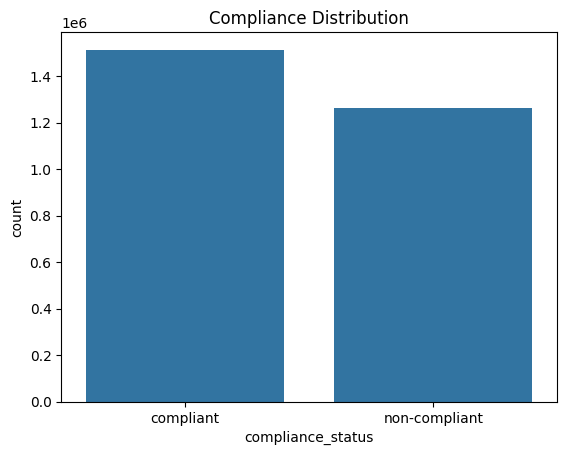

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count plot
sns.countplot(x='compliance_status', data=df)
plt.title("Compliance Distribution")
plt.show()

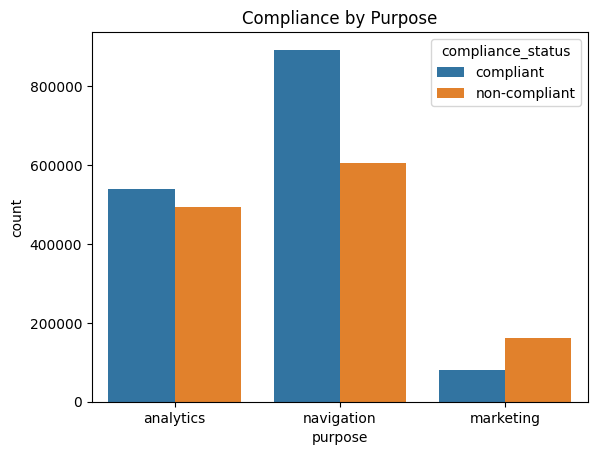

In [ ]:
sns.countplot(x='purpose', hue='compliance_status', data=df)
plt.title("Compliance by Purpose")
plt.show()

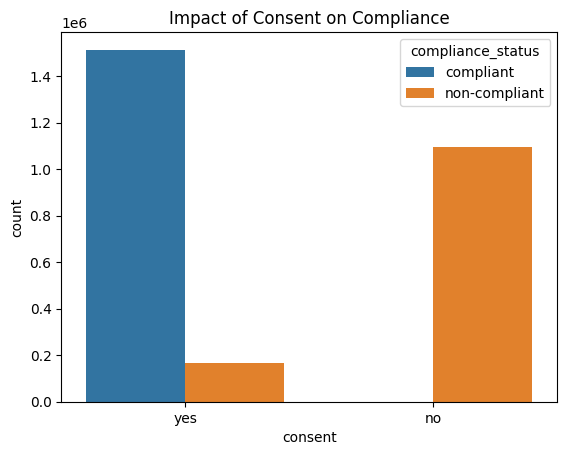

In [ ]:
sns.countplot(x='consent', hue='compliance_status', data=df)
plt.title("Impact of Consent on Compliance")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

# Encode categorical columns
le = LabelEncoder()

for col in ['rideable_type','member_casual','purpose','consent','data_shared','compliance_status']:
    df_model[col] = le.fit_transform(df_model[col])

# Features & target
X = df_model[['rideable_type','member_casual','trip_duration','purpose','distance','risk_score']]
y = df_model['compliance_status']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

X_train.shape

(2221415, 6)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

In [ ]:
import pandas as pd

importances = model.feature_importances_
features = X.columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)
print(feat_imp)

In [ ]:
# ===============================
# STEP 3B: Enhanced Context Features
# ===============================

import numpy as np
import pandas as pd

# 1. Fix consent (make independent)
df['consent'] = np.where(np.random.rand(len(df)) > 0.3, 'yes', 'no')

# 2. Time-based features
df['hour'] = df['started_at'].dt.hour

df['time_of_day'] = pd.cut(
    df['hour'],
    bins=[0,6,12,18,24],
    labels=['night','morning','afternoon','evening']
)

# 3. Distance feature
df['distance'] = ((df['end_lat'] - df['start_lat'])**2 +
                  (df['end_lng'] - df['start_lng'])**2) ** 0.5

# 4. Risk score (context intelligence)
df['risk_score'] = (
    (df['purpose'] == 'marketing').astype(int) * 3 +
    (df['trip_duration'] > 30).astype(int) * 2 +
    (df['distance'] > df['distance'].median()).astype(int) * 2
)

# 5. Recompute compliance (UPDATED LOGIC)
df['compliance_status'] = np.where(
    (df['consent'] == 'no') |
    (df['data_shared'] == 'yes') |
    (df['risk_score'] > 3),
    'non-compliant',
    'compliant'
)

# Check
df[['purpose','consent','distance','risk_score','compliance_status']].head()

,purpose,consent,distance,risk_score,compliance_status
0,analytics,no,0.028456,2,non-compliant
1,analytics,yes,0.034216,2,compliant
2,navigation,yes,0.012400,0,compliant
3,navigation,yes,0.009400,0,compliant
4,analytics,no,0.009400,0,non-compliant
